In [1]:
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid")

In [2]:
def get_stats(filename):
    df = pd.read_csv(filename)
    finish_map = df[df['event_type'] == 'FINISH'].groupby('task_id')['timestamp'].max()
    df_ret = df.groupby('task_id', as_index=False).agg(
                npts=('npts', 'max'),
                start_time=('timestamp', 'min'),
                interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
            )
    df_ret['finish_time'] = df_ret['task_id'].map(finish_map)
    df_ret = df_ret.dropna()
    df_ret['duration_s'] = (df_ret['finish_time'] - df_ret['start_time']) / 1000.0
    return df_ret[['task_id', 'npts', 'start_time', 'interruptions', 'finish_time', 'duration_s']]

In [3]:
def get_aggregated_policy_stats(pattern, limit):
    files = sorted(glob.glob(pattern))
    files = files[:limit]
    all_runs = []
    print(f"Aggregating efficiency for {len(files)} policy runs...")
    for run_idx, f in enumerate(files):
        try:
            df_local = get_stats(f)
            df_selected = df_local[['task_id','npts', 'start_time','finish_time','duration_s', 'interruptions']].copy()
            df_selected['run_id'] = run_idx
            all_runs.append(df_selected)
        except Exception as e:
            continue    
    if not all_runs: return pd.DataFrame()
    return pd.concat(all_runs, ignore_index=True)

In [4]:
print("Processing 100 Policy Simulation logs...")
df_policy_all = get_aggregated_policy_stats("policy_runs/sim_events_*.csv",100)
df_random_all = get_aggregated_policy_stats("random_runs/sim_events_*.csv",100)

Processing 100 Policy Simulation logs...
Aggregating efficiency for 100 policy runs...
Aggregating efficiency for 100 policy runs...


In [5]:
df_policy_all.head()

,task_id,npts,start_time,finish_time,duration_s,interruptions,run_id
0,0,8727197,2000,148000,146.0,0,0
1,1,12550781,599000,838000,239.0,0,0
2,2,12542930,3781000,4004000,223.0,0,0
3,3,12547303,4048000,4272000,224.0,0,0
4,4,7503288,30000,164000,134.0,0,0


In [6]:
# Calculate min, max and avg duration of each task_id across all runs for both policy and random
def calculate_stats(df):
    stats = df.groupby('task_id')['duration_s'].agg(['min', 'max', 'mean']).reset_index()
    stats.columns = ['task_id', 'min_duration', 'max_duration', 'avg_duration']
    stats['cumulative_min'] = stats['min_duration'].cumsum()
    stats['cumulative_max'] = stats['max_duration'].cumsum()
    stats['cumulative_avg'] = stats['avg_duration'].cumsum()
    return stats
policy_stats = calculate_stats(df_policy_all)
random_stats = calculate_stats(df_random_all)


In [7]:
policy_stats.head(10)

,task_id,min_duration,max_duration,avg_duration,cumulative_min,cumulative_max,cumulative_avg
0,0,146.0,335.0,163.09,146.0,335.0,163.09
1,1,239.0,1133.0,320.32,385.0,1468.0,483.41
2,2,223.0,763.0,289.15,608.0,2231.0,772.56
3,3,224.0,1090.0,316.30,832.0,3321.0,1088.86
4,4,134.0,297.0,147.95,966.0,3618.0,1236.81
5,5,162.0,367.0,183.37,1128.0,3985.0,1420.18
6,6,150.0,400.0,170.32,1278.0,4385.0,1590.50
7,7,185.0,990.0,268.04,1463.0,5375.0,1858.54
8,8,154.0,394.0,186.24,1617.0,5769.0,2044.78
9,9,217.0,747.0,274.51,1834.0,6516.0,2319.29


In [10]:
df_ideal = get_stats("sim_events_nopreempt.csv")
#Calculate cumulative duration for ideal case
df_ideal['cumulative_duration'] = df_ideal['duration_s'].cumsum()

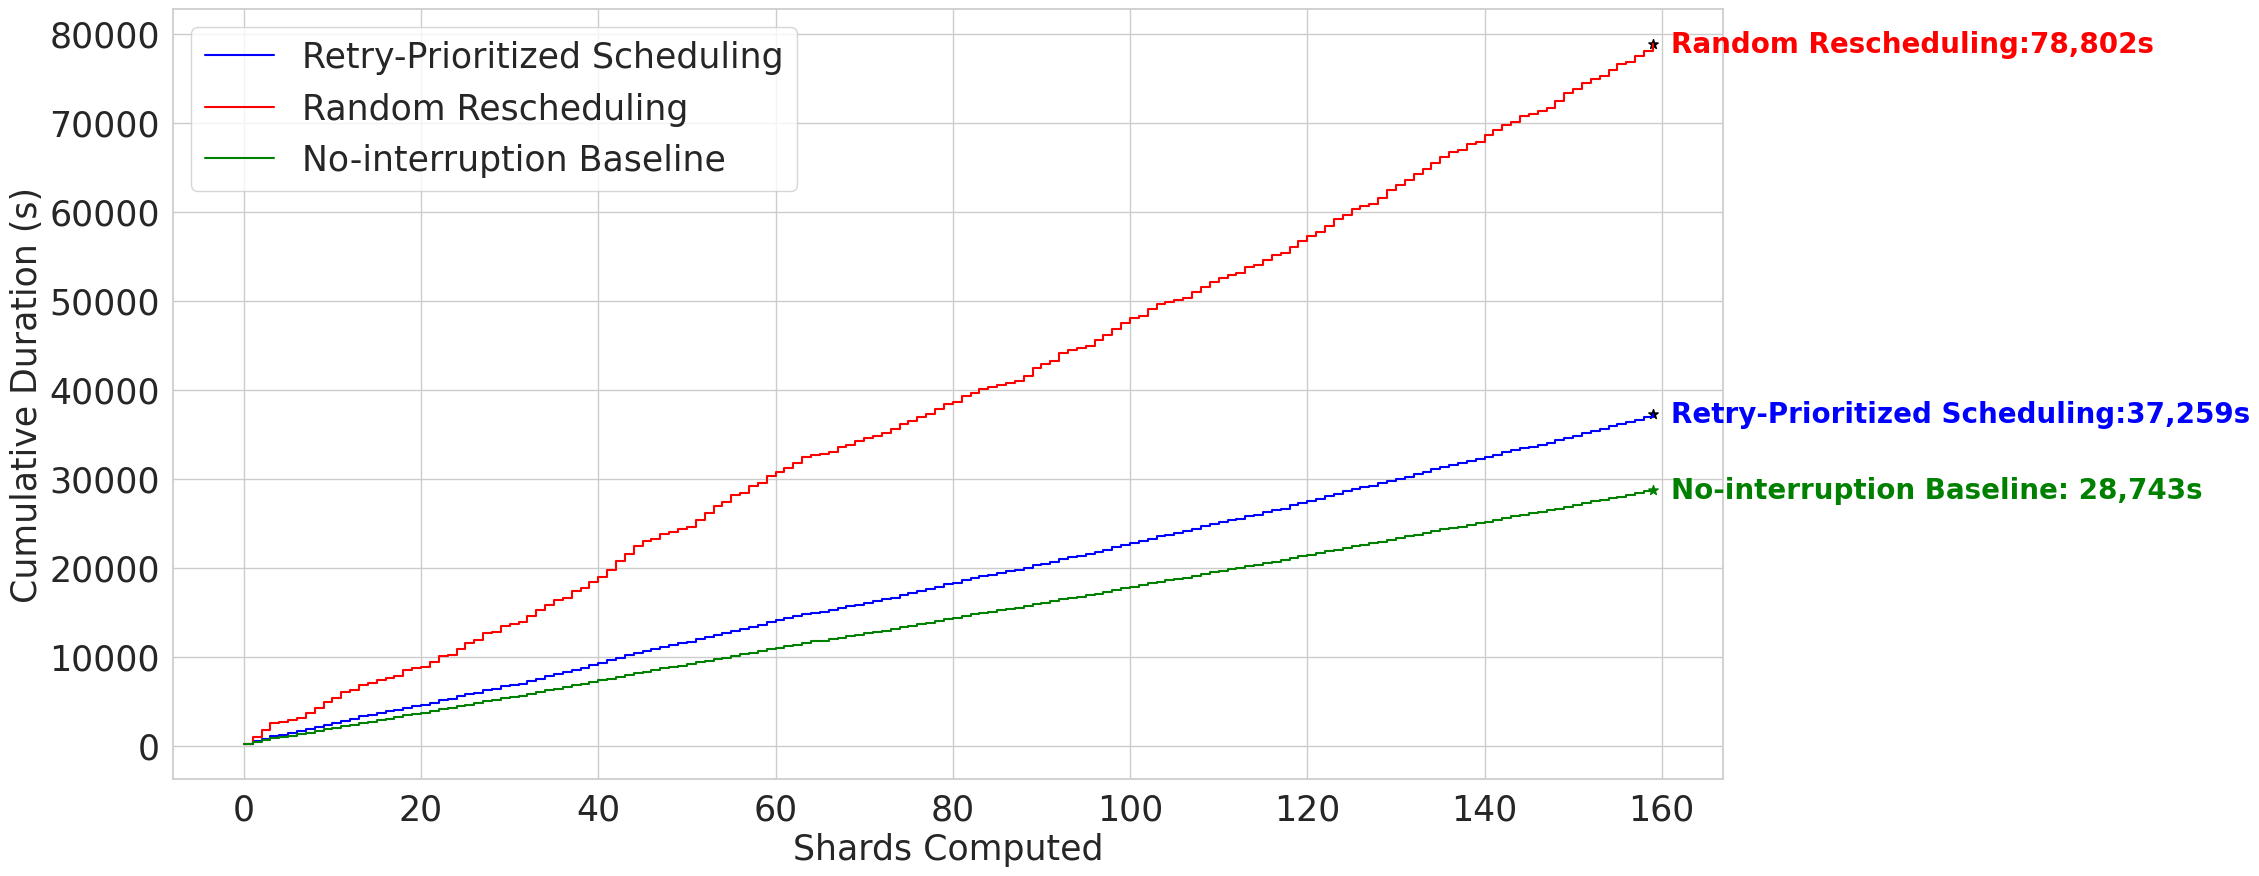

In [39]:
plt.figure(figsize=(20, 10))

def plot_stair(df, label_prefix, color_avg):
    plt.step(df['task_id'], df['cumulative_avg'], where='post', label=f'{label_prefix}', color=color_avg)

    px = df['task_id'].iloc[-1]
    py = df['cumulative_avg'].iloc[-1]
    plt.scatter(px,py,color='black', marker='*',s=50)
    plt.text(px + 2, py, f'{label_prefix}:{py:,.0f}s', fontsize=20, fontweight='bold', color=color_avg, ha='left', va='center')
    #Add label for each policy

plot_stair(policy_stats, 'Retry-Prioritized Scheduling', 'blue')
plot_stair(random_stats, 'Random Rescheduling', 'red')

plt.step(df_ideal['task_id'], df_ideal['cumulative_duration'], where='post', label='No-interruption Baseline', color='green')
px_ideal = df_ideal['task_id'].iloc[-1]
py_ideal = df_ideal['cumulative_duration'].iloc[-1]
plt.scatter(px_ideal, py_ideal, color='green', marker='*',s=50)
plt.text(px_ideal + 2, py_ideal, f'No-interruption Baseline: {py_ideal:,.0f}s',fontsize=20, fontweight='bold', color='green', ha='left', va='center')

plt.xlabel('Shards Computed',fontsize=25)
plt.ylabel('Cumulative Duration (s)',fontsize=25)
plt.rc('xtick', labelsize=25)    # fontsize of the tick labels
plt.rc('ytick', labelsize=25)    # fontsize of the tick labels
plt.legend(fontsize=25)
plt.grid(True)